In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset

df = pd.read_csv("osteoporosis.csv")

In [3]:
df

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1953,106130,19,Female,Normal,Yes,African American,Normal,Adequate,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,NaN,Yes,0
1954,106463,23,Female,Postmenopausal,Yes,Caucasian,Underweight,Low,Insufficient,Active,No,NaN,NaN,Corticosteroids,No,0
1955,103142,34,Female,Postmenopausal,No,African American,Underweight,Low,Sufficient,Sedentary,No,NaN,Hyperthyroidism,NaN,No,0
1956,105187,25,Male,Postmenopausal,No,African American,Normal,Low,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,Yes,0


In [4]:
df.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


In [5]:
df.shape

(1958, 16)

In [6]:
df.columns

Index(['Id', 'Age', 'Gender', 'Hormonal Changes', 'Family History',
       'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1958 non-null   int64 
 1   Age                  1958 non-null   int64 
 2   Gender               1958 non-null   object
 3   Hormonal Changes     1958 non-null   object
 4   Family History       1958 non-null   object
 5   Race/Ethnicity       1958 non-null   object
 6   Body Weight          1958 non-null   object
 7   Calcium Intake       1958 non-null   object
 8   Vitamin D Intake     1958 non-null   object
 9   Physical Activity    1958 non-null   object
 10  Smoking              1958 non-null   object
 11  Alcohol Consumption  970 non-null    object
 12  Medical Conditions   1311 non-null   object
 13  Medications          973 non-null    object
 14  Prior Fractures      1958 non-null   object
 15  Osteoporosis         1958 non-null   int64 
dtypes: int

In [8]:
df.isnull().sum()                                        # no. of missing values in every columns

Id                       0
Age                      0
Gender                   0
Hormonal Changes         0
Family History           0
Race/Ethnicity           0
Body Weight              0
Calcium Intake           0
Vitamin D Intake         0
Physical Activity        0
Smoking                  0
Alcohol Consumption    988
Medical Conditions     647
Medications            985
Prior Fractures          0
Osteoporosis             0
dtype: int64

In [9]:
# check duplicate IDs

df['Id'].duplicated().sum()

np.int64(209)

In [10]:
df[df["Id"].duplicated(keep=False)].sort_values("Id")

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
77,101027,82,Female,Normal,No,Asian,Underweight,Low,Insufficient,Active,No,Moderate,NaN,Corticosteroids,No,1
1497,101027,29,Female,Postmenopausal,Yes,Caucasian,Normal,Low,Insufficient,Active,No,Moderate,NaN,Corticosteroids,No,0
1544,101148,25,Female,Postmenopausal,No,African American,Underweight,Low,Insufficient,Active,No,Moderate,Hyperthyroidism,NaN,No,0
736,101148,21,Male,Normal,Yes,Asian,Normal,Adequate,Insufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,No,1
720,101162,59,Female,Postmenopausal,Yes,African American,Underweight,Low,Sufficient,Active,Yes,Moderate,Hyperthyroidism,NaN,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1432,109820,21,Male,Normal,Yes,Asian,Underweight,Adequate,Sufficient,Active,No,Moderate,Rheumatoid Arthritis,NaN,Yes,0
421,109835,19,Male,Normal,No,Asian,Normal,Low,Insufficient,Sedentary,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
1799,109835,34,Male,Postmenopausal,No,Asian,Normal,Adequate,Insufficient,Active,Yes,Moderate,Hyperthyroidism,NaN,Yes,0
1370,109986,18,Male,Postmenopausal,Yes,African American,Normal,Low,Insufficient,Sedentary,No,NaN,Hyperthyroidism,Corticosteroids,No,0


In [11]:
df.loc[df['Id'].duplicated(keep=False), 'Id'].nunique()

196

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Gender'].value_counts()

Gender
Male      992
Female    966
Name: count, dtype: int64

In [14]:
df['Hormonal Changes'].value_counts()

Hormonal Changes
Normal            981
Postmenopausal    977
Name: count, dtype: int64

In [15]:
df['Family History'].value_counts()

Family History
No     998
Yes    960
Name: count, dtype: int64

In [16]:
df['Race/Ethnicity'].value_counts()

Race/Ethnicity
African American    681
Caucasian           646
Asian               631
Name: count, dtype: int64

In [17]:
df['Body Weight'].value_counts()

Body Weight
Normal         1027
Underweight     931
Name: count, dtype: int64

In [18]:
df['Calcium Intake'].value_counts()

Calcium Intake
Low         1004
Adequate     954
Name: count, dtype: int64

In [19]:
df['Vitamin D Intake'].value_counts()

Vitamin D Intake
Sufficient      1011
Insufficient     947
Name: count, dtype: int64

In [20]:
df['Physical Activity'].value_counts()

Physical Activity
Active       1021
Sedentary     937
Name: count, dtype: int64

In [21]:
df['Smoking'].value_counts()

Smoking
Yes    982
No     976
Name: count, dtype: int64

In [22]:
df['Alcohol Consumption'].value_counts()

Alcohol Consumption
Moderate    970
Name: count, dtype: int64

In [23]:
df['Medical Conditions'].value_counts()

Medical Conditions
Hyperthyroidism         678
Rheumatoid Arthritis    633
Name: count, dtype: int64

In [24]:
df['Medications'].value_counts()

Medications
Corticosteroids    973
Name: count, dtype: int64

In [25]:
df['Prior Fractures'].value_counts()
df['Osteoporosis'].value_counts()

Osteoporosis
1    979
0    979
Name: count, dtype: int64

In [26]:
df.isnull().sum()

Id                       0
Age                      0
Gender                   0
Hormonal Changes         0
Family History           0
Race/Ethnicity           0
Body Weight              0
Calcium Intake           0
Vitamin D Intake         0
Physical Activity        0
Smoking                  0
Alcohol Consumption    988
Medical Conditions     647
Medications            985
Prior Fractures          0
Osteoporosis             0
dtype: int64

## Data Cleaning

In [27]:
df['Alcohol Consumption'] = df['Alcohol Consumption'].fillna('Unknown')

In [28]:
df['Alcohol Consumption'].value_counts()

Alcohol Consumption
Unknown     988
Moderate    970
Name: count, dtype: int64

In [29]:
df['Medical Conditions'] = df['Medical Conditions'].fillna('Unknown')

In [30]:
df['Medical Conditions'].value_counts()

Medical Conditions
Hyperthyroidism         678
Unknown                 647
Rheumatoid Arthritis    633
Name: count, dtype: int64

In [31]:
df['Medications'] = df['Medications'].fillna('Unknown')

In [32]:
df['Medications'].value_counts()

Medications
Unknown            985
Corticosteroids    973
Name: count, dtype: int64

In [33]:
df.isnull().sum()

Id                     0
Age                    0
Gender                 0
Hormonal Changes       0
Family History         0
Race/Ethnicity         0
Body Weight            0
Calcium Intake         0
Vitamin D Intake       0
Physical Activity      0
Smoking                0
Alcohol Consumption    0
Medical Conditions     0
Medications            0
Prior Fractures        0
Osteoporosis           0
dtype: int64

In [34]:
df['Age'].describe()

count    1958.000000
mean       39.101124
std        21.355424
min        18.000000
25%        21.000000
50%        32.000000
75%        53.000000
max        90.000000
Name: Age, dtype: float64

## EDA 

In [35]:
# check target variable

df['Osteoporosis'].value_counts()

Osteoporosis
1    979
0    979
Name: count, dtype: int64

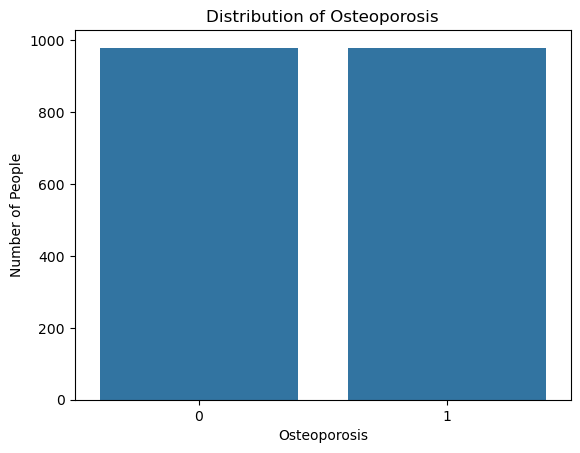

In [36]:
# visualize the target distribution

sns.countplot(x = "Osteoporosis", data=df)
plt.title('Distribution of Osteoporosis')
plt.xlabel('Osteoporosis')
plt.ylabel('Number of People')
plt.show()

In [37]:
# exploring Age

df['Age'].describe()

count    1958.000000
mean       39.101124
std        21.355424
min        18.000000
25%        21.000000
50%        32.000000
75%        53.000000
max        90.000000
Name: Age, dtype: float64

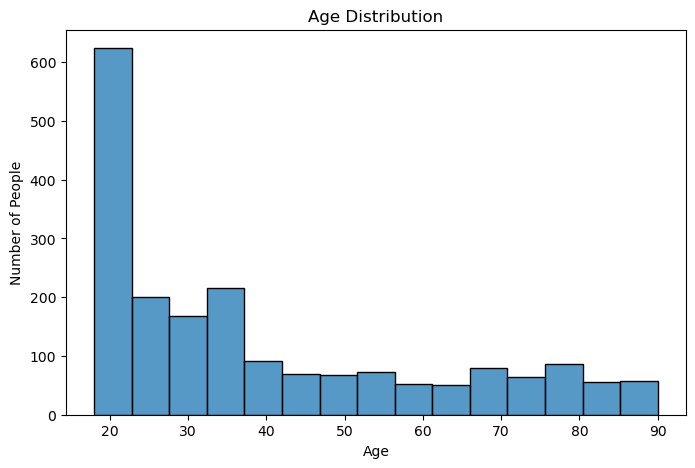

In [38]:
# visualize Age ditribution

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15)
plt.title("Age Distribution")
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.show()

In [39]:
# Create Age Groups

age_bins = [18,29,39,49,59,69,79,90]
age_labels = ['18-29', '30-39', '40-49','50-59','60-69','70-79','80-90']

df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, include_lowest = True)

In [40]:
df['Age Group'].value_counts().sort_index()

Age Group
18-29    951
30-39    314
40-49    138
50-59    140
60-69    135
70-79    146
80-90    134
Name: count, dtype: int64

In [41]:
# compare age group with osteoporosis 

pd.crosstab(df['Age Group'],df['Osteoporosis'])

Osteoporosis,0,1
Age Group,,
18-29,794,157
30-39,185,129
40-49,0,138
50-59,0,140
60-69,0,135
70-79,0,146
80-90,0,134


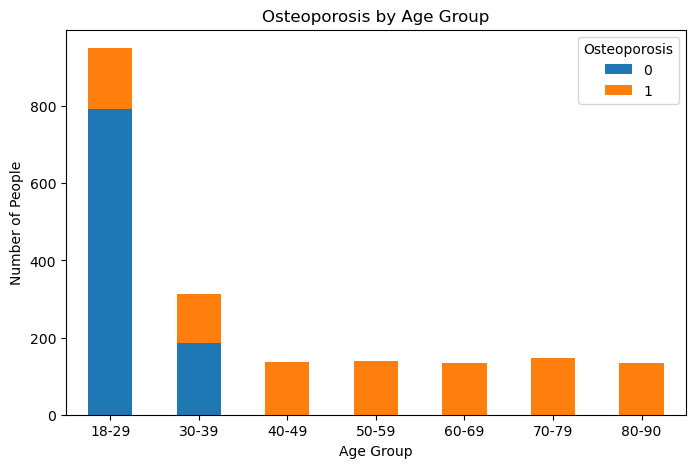

In [42]:
# Age group vs Osteoporosis

age_osteoporosis = pd.crosstab(df['Age Group'],df['Osteoporosis'])

age_osteoporosis.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Osteoporosis by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [43]:
# Gender Analysis

# count male and female

df['Gender'].value_counts()

Gender
Male      992
Female    966
Name: count, dtype: int64

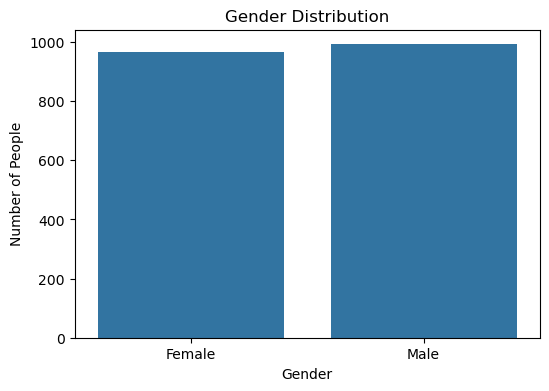

In [44]:
# visualize Gender

plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of People')
plt.show()

In [45]:
gender_osteoporosis = pd.crosstab(df['Gender'],df['Osteoporosis'])
gender_osteoporosis

Osteoporosis,0,1
Gender,,
Female,489,477
Male,490,502


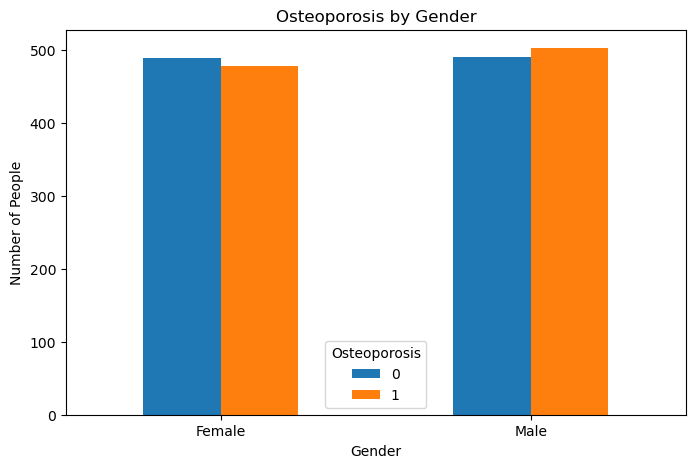

In [46]:
gender_osteoporosis.plot(kind='bar', figsize=(8,5))

plt.title('Osteoporosis by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [47]:
# Hormonal Changes

df['Hormonal Changes'].value_counts()

Hormonal Changes
Normal            981
Postmenopausal    977
Name: count, dtype: int64

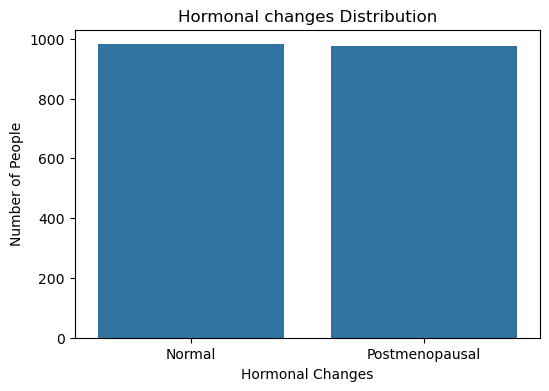

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x='Hormonal Changes', data=df)

plt.title('Hormonal changes Distribution')
plt.xlabel('Hormonal Changes')
plt.ylabel('Number of People')
plt.show()

In [49]:
hormonal_osteoporosis = pd.crosstab(df['Hormonal Changes'], df['Osteoporosis'])
hormonal_osteoporosis

Osteoporosis,0,1
Hormonal Changes,,
Normal,498,483
Postmenopausal,481,496


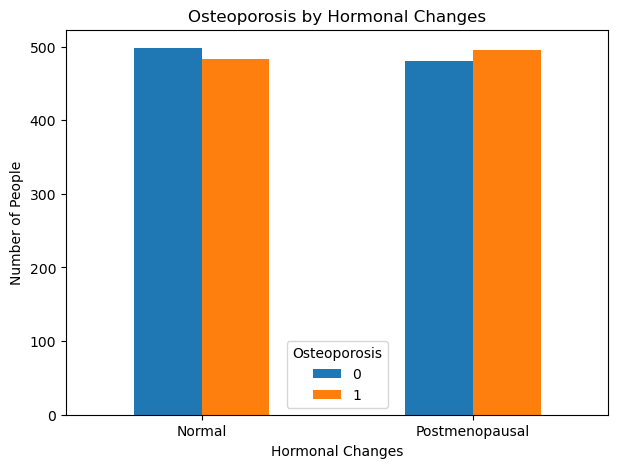

In [50]:
hormonal_osteoporosis.plot(kind='bar', figsize=(7, 5))

plt.title('Osteoporosis by Hormonal Changes')
plt.xlabel('Hormonal Changes')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [51]:
# Family history

df['Family History'].value_counts()

Family History
No     998
Yes    960
Name: count, dtype: int64

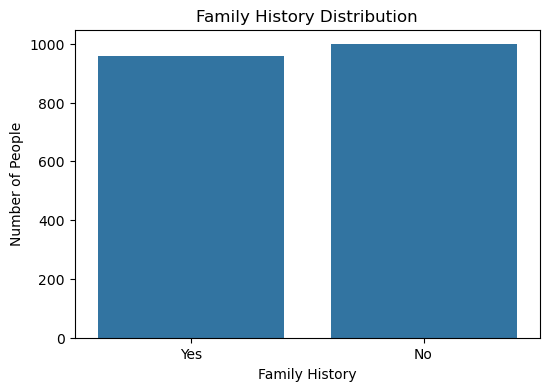

In [52]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Family History', data=df)

plt.title('Family History Distribution')
plt.xlabel('Family History')
plt.ylabel('Number of People')
plt.show()

In [53]:
family_osteoporosis = pd.crosstab(df['Family History'], df['Osteoporosis'])
family_osteoporosis

Osteoporosis,0,1
Family History,,
No,498,500
Yes,481,479


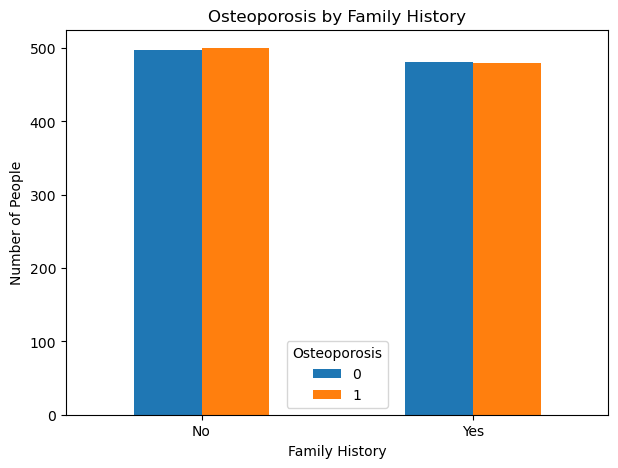

In [54]:
family_osteoporosis.plot(kind='bar', figsize=(7, 5))

plt.title('Osteoporosis by Family History')
plt.xlabel('Family History')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [55]:
# Race/Ethnicity

df['Race/Ethnicity'].value_counts()

Race/Ethnicity
African American    681
Caucasian           646
Asian               631
Name: count, dtype: int64

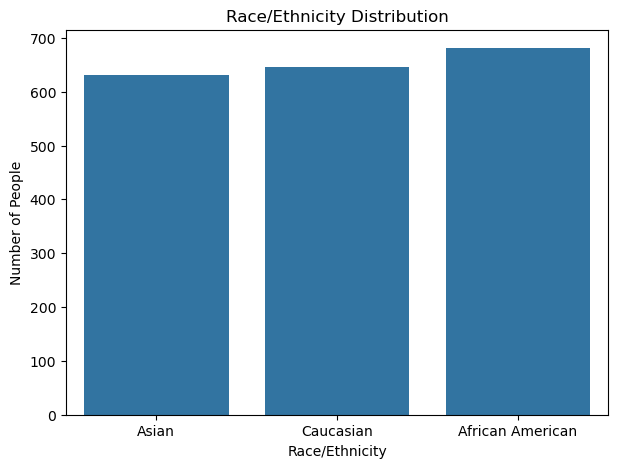

In [56]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Race/Ethnicity', data=df)

plt.title('Race/Ethnicity Distribution')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.show()

In [57]:
race_osteoporosis = pd.crosstab(df['Race/Ethnicity'], df['Osteoporosis'])
race_osteoporosis

Osteoporosis,0,1
Race/Ethnicity,,
African American,337,344
Asian,317,314
Caucasian,325,321


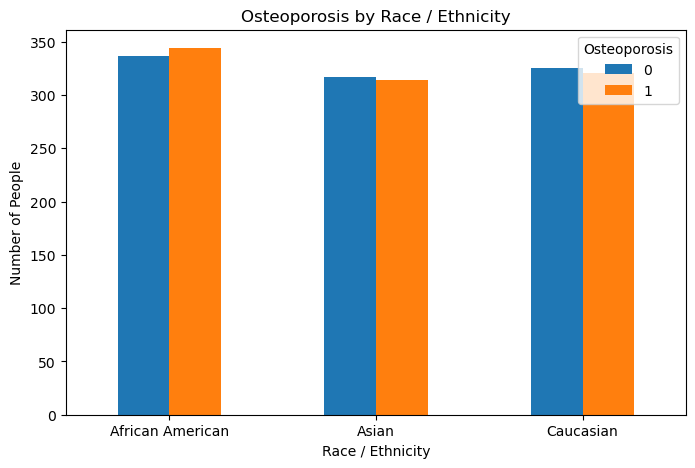

In [58]:
race_osteoporosis.plot(kind='bar', figsize=(8, 5))

plt.title('Osteoporosis by Race / Ethnicity')
plt.xlabel('Race / Ethnicity')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [59]:
# Body weight

df['Body Weight'].value_counts()

Body Weight
Normal         1027
Underweight     931
Name: count, dtype: int64

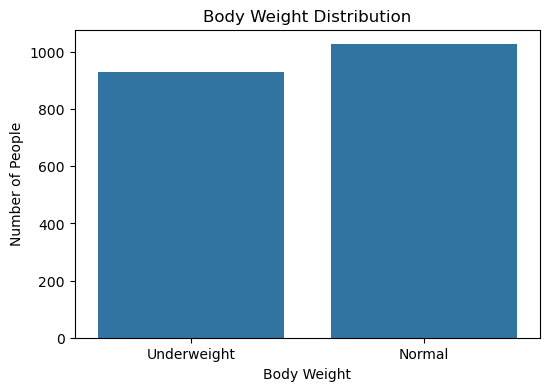

In [60]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Body Weight', data=df)

plt.title('Body Weight Distribution')
plt.xlabel('Body Weight')
plt.ylabel('Number of People')
plt.show()

In [61]:
weight_osteoporosis = pd.crosstab(df['Body Weight'], df['Osteoporosis'])
weight_osteoporosis

Osteoporosis,0,1
Body Weight,,
Normal,531,496
Underweight,448,483


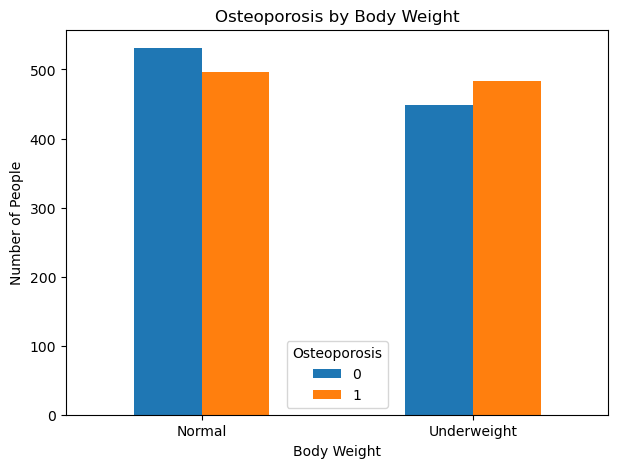

In [62]:
weight_osteoporosis.plot(kind='bar', figsize=(7, 5))

plt.title('Osteoporosis by Body Weight')
plt.xlabel('Body Weight')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [63]:
df['Calcium Intake'].value_counts()

Calcium Intake
Low         1004
Adequate     954
Name: count, dtype: int64

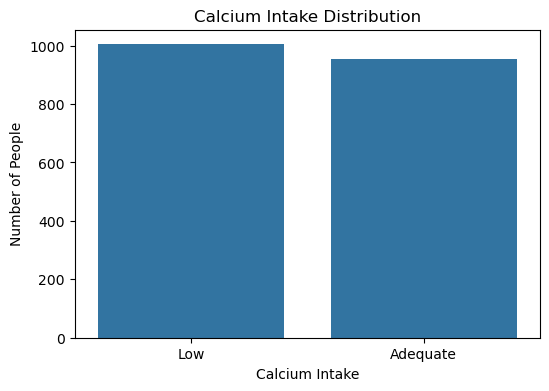

In [64]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Calcium Intake', data=df)

plt.title('Calcium Intake Distribution')
plt.xlabel('Calcium Intake')
plt.ylabel('Number of People')
plt.show()

In [65]:
calcium_osteoporosis = pd.crosstab(df['Calcium Intake'], df['Osteoporosis'])
calcium_osteoporosis

Osteoporosis,0,1
Calcium Intake,,
Adequate,475,479
Low,504,500


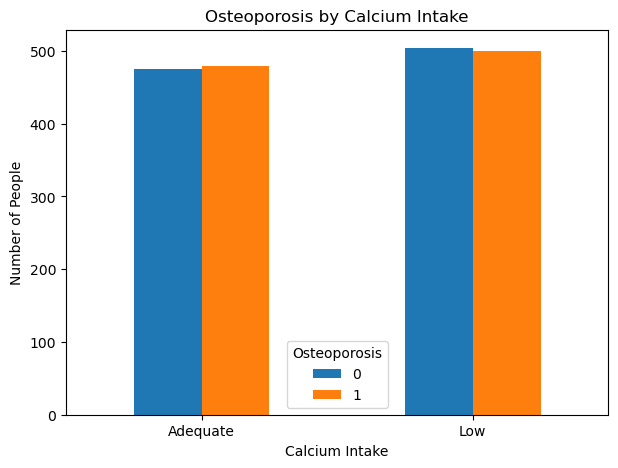

In [66]:
calcium_osteoporosis.plot(kind='bar', figsize=(7, 5))

plt.title('Osteoporosis by Calcium Intake')
plt.xlabel('Calcium Intake')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [67]:
df['Vitamin D Intake'].value_counts()

Vitamin D Intake
Sufficient      1011
Insufficient     947
Name: count, dtype: int64

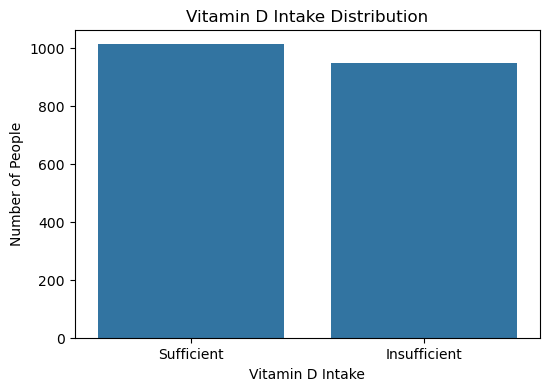

In [68]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Vitamin D Intake', data=df)

plt.title('Vitamin D Intake Distribution')
plt.xlabel('Vitamin D Intake')
plt.ylabel('Number of People')
plt.show()

In [69]:
vitamin_d_osteoporosis = pd.crosstab(df['Vitamin D Intake'], df['Osteoporosis'])
vitamin_d_osteoporosis

Osteoporosis,0,1
Vitamin D Intake,,
Insufficient,482,465
Sufficient,497,514


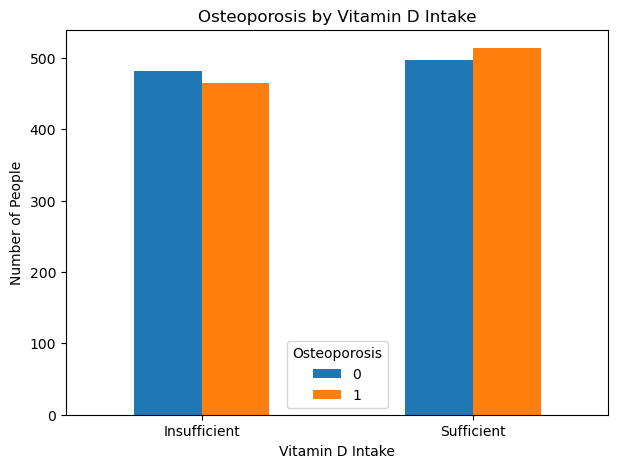

In [70]:
vitamin_d_osteoporosis.plot(kind='bar', figsize=(7, 5))

plt.title('Osteoporosis by Vitamin D Intake')
plt.xlabel('Vitamin D Intake')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [71]:
df['Physical Activity'].value_counts()

Physical Activity
Active       1021
Sedentary     937
Name: count, dtype: int64

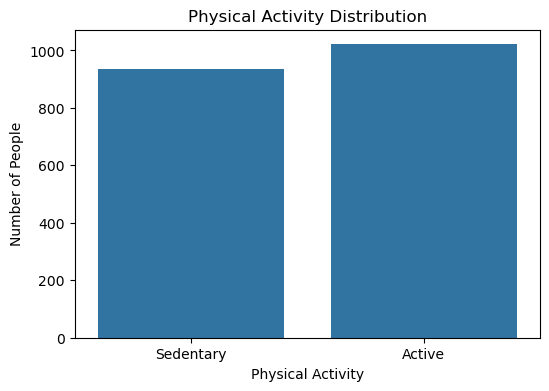

In [72]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Physical Activity', data=df)

plt.title('Physical Activity Distribution')
plt.xlabel('Physical Activity')
plt.ylabel('Number of People')
plt.show()

In [73]:
physical_osteoporosis = pd.crosstab(df['Physical Activity'], df['Osteoporosis'])
physical_osteoporosis

Osteoporosis,0,1
Physical Activity,,
Active,520,501
Sedentary,459,478


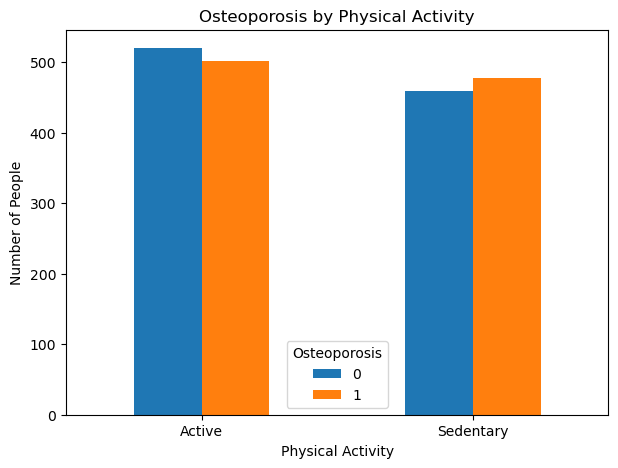

In [74]:
physical_osteoporosis.plot(kind='bar', figsize=(7, 5))

plt.title('Osteoporosis by Physical Activity')
plt.xlabel('Physical Activity')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [75]:
df['Smoking'].value_counts()

Smoking
Yes    982
No     976
Name: count, dtype: int64

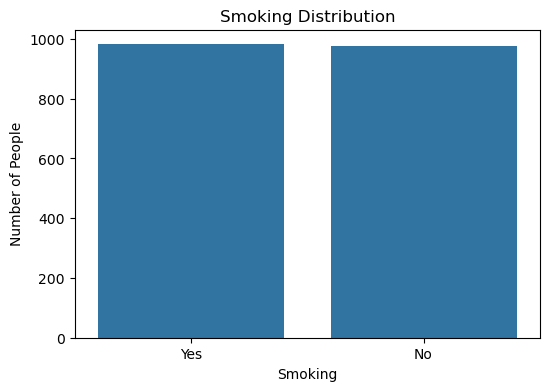

In [76]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Smoking', data=df)

plt.title('Smoking Distribution')
plt.xlabel('Smoking')
plt.ylabel('Number of People')
plt.show()

In [77]:
smoking_osteoporosis = pd.crosstab(df['Smoking'], df['Osteoporosis'])
smoking_osteoporosis

Osteoporosis,0,1
Smoking,,
No,480,496
Yes,499,483


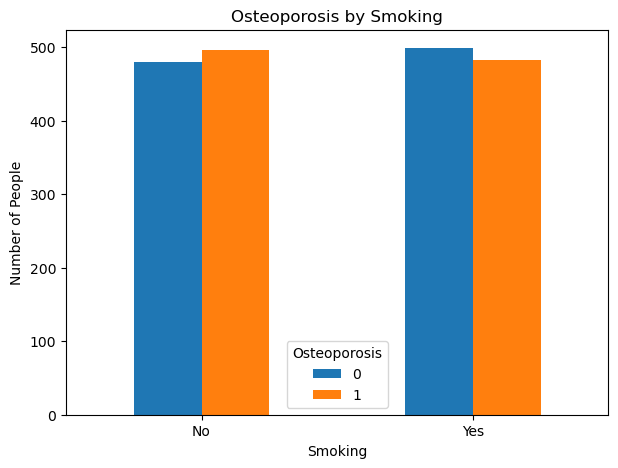

In [78]:
smoking_osteoporosis.plot(kind='bar', figsize=(7, 5))

plt.title('Osteoporosis by Smoking')
plt.xlabel('Smoking')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Osteoporosis')
plt.show()

In [79]:
df["Alcohol Consumption"].value_counts()

Alcohol Consumption
Unknown     988
Moderate    970
Name: count, dtype: int64

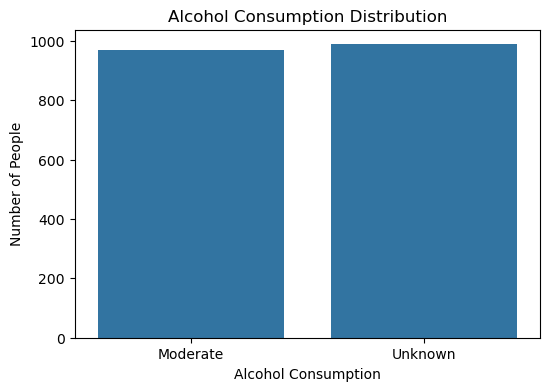

In [80]:
plt.figure(figsize=(6,4))
sns.countplot(x='Alcohol Consumption', data=df)

plt.title("Alcohol Consumption Distribution")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Number of People")
plt.show()

In [81]:
alcohol_osteoporosis = pd.crosstab(df['Alcohol Consumption'],df['Osteoporosis'])
alcohol_osteoporosis

Osteoporosis,0,1
Alcohol Consumption,,
Moderate,484,486
Unknown,495,493


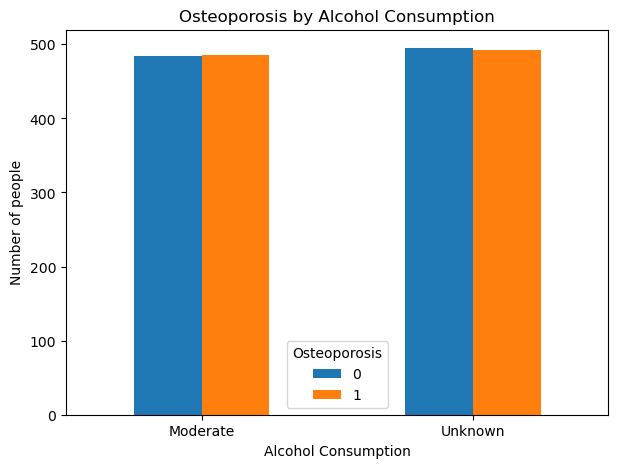

In [82]:
alcohol_osteoporosis.plot(kind='bar',figsize=(7,5))

plt.title("Osteoporosis by Alcohol Consumption")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Number of people")
plt.xticks(rotation=0)
plt.legend(title="Osteoporosis")
plt.show()

In [83]:
df["Medical Conditions"].value_counts()

Medical Conditions
Hyperthyroidism         678
Unknown                 647
Rheumatoid Arthritis    633
Name: count, dtype: int64

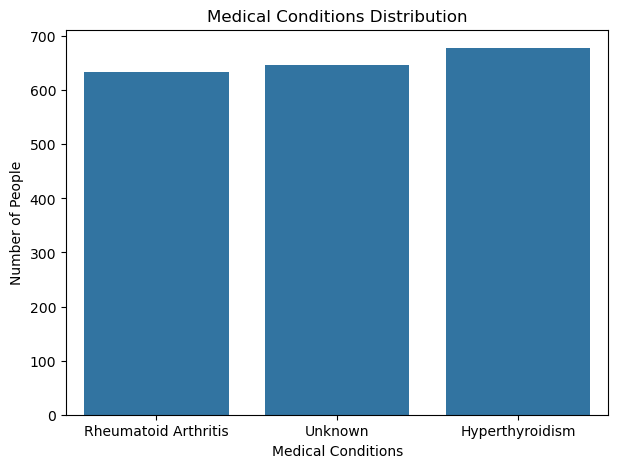

In [84]:
plt.figure(figsize=(7,5))
sns.countplot(x='Medical Conditions', data=df)

plt.title("Medical Conditions Distribution")
plt.xlabel("Medical Conditions")
plt.ylabel("Number of People")
plt.show()

In [85]:
medical_osteoporosis = pd.crosstab(df['Medical Conditions'],df['Osteoporosis'])
medical_osteoporosis

Osteoporosis,0,1
Medical Conditions,,
Hyperthyroidism,335,343
Rheumatoid Arthritis,315,318
Unknown,329,318


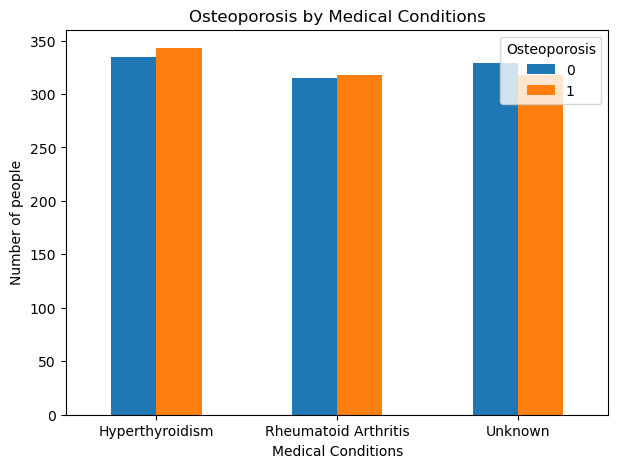

In [86]:
medical_osteoporosis.plot(kind='bar', figsize=(7,5))

plt.title("Osteoporosis by Medical Conditions")
plt.xlabel("Medical Conditions")
plt.ylabel("Number of people")
plt.xticks(rotation=0)
plt.legend(title="Osteoporosis")
plt.show()

In [87]:
df["Medications"].value_counts()

Medications
Unknown            985
Corticosteroids    973
Name: count, dtype: int64

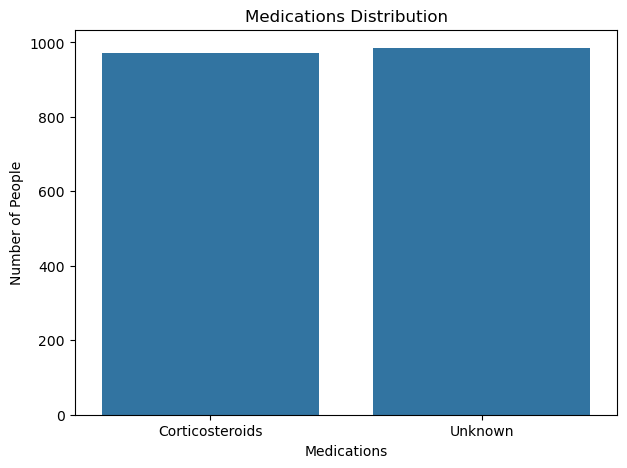

In [88]:
plt.figure(figsize=(7,5))
sns.countplot(x='Medications', data=df)

plt.title("Medications Distribution")
plt.xlabel("Medications")
plt.ylabel("Number of People")
plt.show()

In [89]:
medications_osteoporosis = pd.crosstab(df['Medications'],df['Osteoporosis'])
medications_osteoporosis

Osteoporosis,0,1
Medications,,
Corticosteroids,470,503
Unknown,509,476


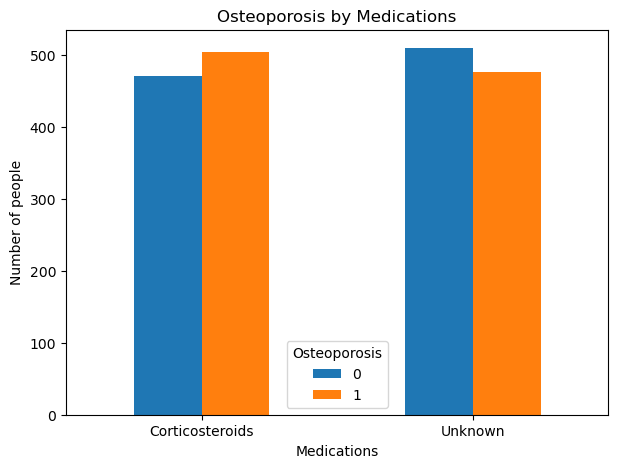

In [90]:
medications_osteoporosis.plot(kind='bar', figsize=(7,5))

plt.title("Osteoporosis by Medications")
plt.xlabel("Medications")
plt.ylabel("Number of people")
plt.xticks(rotation=0)
plt.legend(title="Osteoporosis")
plt.show()

In [91]:
df["Prior Fractures"].value_counts()

Prior Fractures
Yes    983
No     975
Name: count, dtype: int64

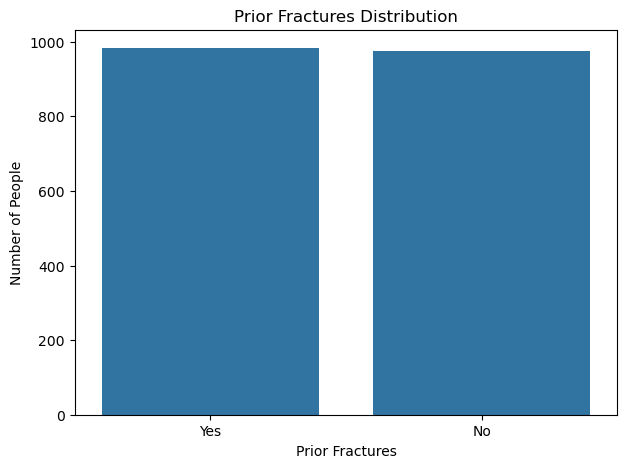

In [92]:
plt.figure(figsize=(7,5))
sns.countplot(x='Prior Fractures', data=df)

plt.title("Prior Fractures Distribution")
plt.xlabel("Prior Fractures")
plt.ylabel("Number of People")
plt.show()

In [93]:
fractures_osteoporosis = pd.crosstab(df['Prior Fractures'],df['Osteoporosis'])
fractures_osteoporosis

Osteoporosis,0,1
Prior Fractures,,
No,495,480
Yes,484,499


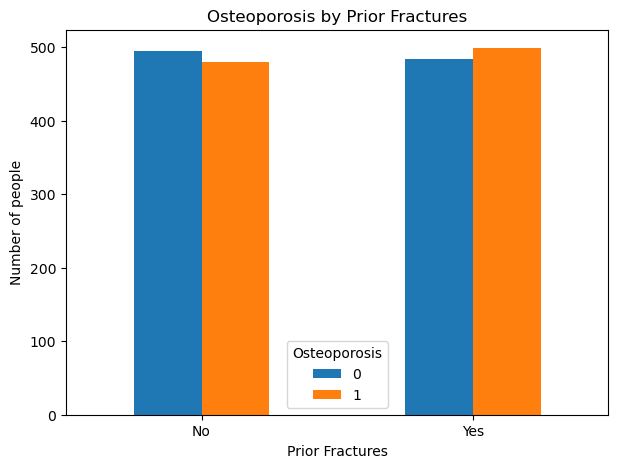

In [94]:
fractures_osteoporosis.plot(kind='bar', figsize=(7,5))

plt.title("Osteoporosis by Prior Fractures")
plt.xlabel("Prior Fractures")
plt.ylabel("Number of people")
plt.xticks(rotation=0)
plt.legend(title="Osteoporosis")
plt.show()

## Data Preprocessing

In [95]:
# Seperating features and target variable

X = df.drop(columns=['Osteoporosis'])
y = df['Osteoporosis']

print("Features shape:",X.shape)
print("Target shape:", y.shape)

Features shape: (1958, 16)
Target shape: (1958,)


In [96]:
# Remove ID and EDA-only Age Group

X = X.drop(columns=['Id', 'Age Group'])

print("Updated features shape:", X.shape)

Updated features shape: (1958, 14)


In [97]:
# check data types of features

X.dtypes

Age                     int64
Gender                 object
Hormonal Changes       object
Family History         object
Race/Ethnicity         object
Body Weight            object
Calcium Intake         object
Vitamin D Intake       object
Physical Activity      object
Smoking                object
Alcohol Consumption    object
Medical Conditions     object
Medications            object
Prior Fractures        object
dtype: object

In [98]:
# Identify Categorical Features

categorical_features = X.select_dtypes(include='object').columns

print("Categorical Features:")
print(list(categorical_features))

Categorical Features:
['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures']


In [99]:
# Encode Categorical Variables

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Encoded data shape:", X_encoded.shape)

Encoded data shape: (1958, 16)


In [100]:
# Display Encoded Features

X_encoded.head()

,Age,Gender_Male,Hormonal Changes_Postmenopausal,Family History_Yes,Race/Ethnicity_Asian,Race/Ethnicity_Caucasian,Body Weight_Underweight,Calcium Intake_Low,Vitamin D Intake_Sufficient,Physical Activity_Sedentary,Smoking_Yes,Alcohol Consumption_Unknown,Medical Conditions_Rheumatoid Arthritis,Medical Conditions_Unknown,Medications_Unknown,Prior Fractures_Yes
0,69,0,0,1,1,0,1,1,1,1,1,0,1,0,0,1
1,32,0,0,1,1,0,1,1,1,1,0,1,0,1,1,1
2,89,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
3,78,0,0,0,0,1,1,0,0,1,1,1,1,0,0,0
4,38,1,1,1,0,0,0,1,1,0,1,1,1,0,1,1


In [101]:
# split the data and testing the test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Training features:",X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:",y_test.shape)

Training features: (1566, 16)
Testing features: (392, 16)
Training target: (1566,)
Testing target: (392,)


In [102]:
# Check Target Distribution in Training and Testing Data

print("Training Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Target Distribution:
Osteoporosis
0    783
1    783
Name: count, dtype: int64

Testing Target Distribution:
Osteoporosis
1    196
0    196
Name: count, dtype: int64


## Model Building

In [103]:
# Logistic Regression

In [104]:
# Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train, y_train)

print("Logistic Regression Model trained successfully")

Logistic Regression Model trained successfully


In [105]:
# Make Predictions using Logistic Regression

y_pred_lr = logistic_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [106]:
# Evaluate Logistic Regression

from sklearn.metrics import accuracy_score, classification_report

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8086734693877551

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       196
           1       0.86      0.74      0.79       196

    accuracy                           0.81       392
   macro avg       0.81      0.81      0.81       392
weighted avg       0.81      0.81      0.81       392



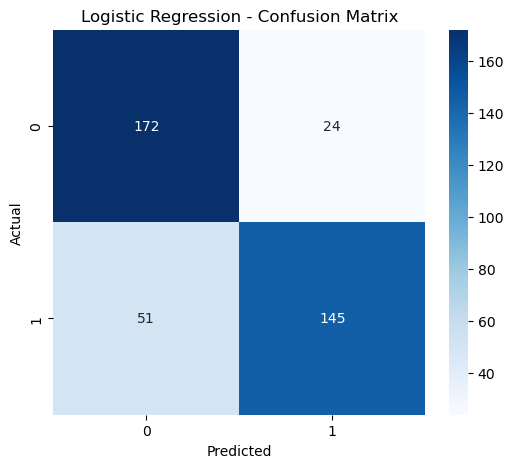

In [107]:
# Confusion Matrix for Logistic Regression

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [108]:
# Decision Tree

# import decision tree

from sklearn.tree import DecisionTreeClassifier


In [109]:
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train,y_train)
print("Decision Tree model trained successfully")

Decision Tree model trained successfully


In [110]:
# make predictions

y_pred_tree = decision_tree_model.predict(X_test)
print(y_pred_tree[:10])

[0 1 1 0 0 1 1 1 1 0]


In [111]:
# calculate accuracy

from sklearn.metrics import accuracy_score
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print("Decision Tree accuracy:", accuracy_tree)

Decision Tree accuracy: 0.8188775510204082


In [112]:
# classification report

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       196
           1       0.84      0.79      0.81       196

    accuracy                           0.82       392
   macro avg       0.82      0.82      0.82       392
weighted avg       0.82      0.82      0.82       392



In [113]:
# confusion matrix

cm_tree = confusion_matrix(y_test, y_pred_tree)
print(cm_tree)

[[166  30]
 [ 41 155]]


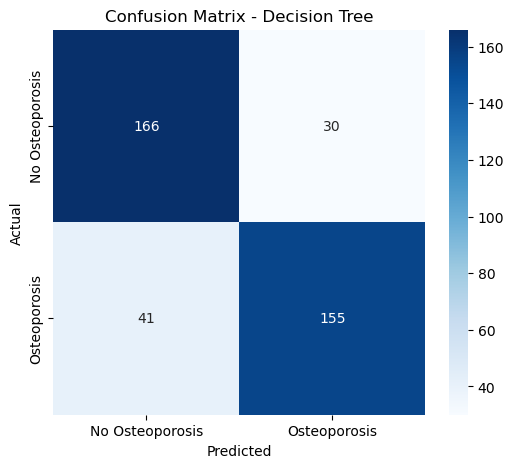

In [114]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Osteoporosis', 'Osteoporosis'],
    yticklabels=['No Osteoporosis', 'Osteoporosis']
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [115]:
# Random Forest

In [116]:
# import random forest

from sklearn.ensemble import RandomForestClassifier

In [117]:
# train the model

random_forest_model = RandomForestClassifier(
    n_estimators=100,                                               #tells the Random Forest to build 100 Decision Trees.
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [118]:
# make predictions

y_pred_rf = random_forest_model.predict(X_test)

print(y_pred_rf[:10])

[0 0 1 0 0 1 1 1 1 0]


In [119]:
# accuracy

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8290816326530612


In [120]:
# classification report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.76      0.96      0.85       196
           1       0.94      0.70      0.80       196

    accuracy                           0.83       392
   macro avg       0.85      0.83      0.83       392
weighted avg       0.85      0.83      0.83       392



In [121]:
# confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[188   8]
 [ 59 137]]


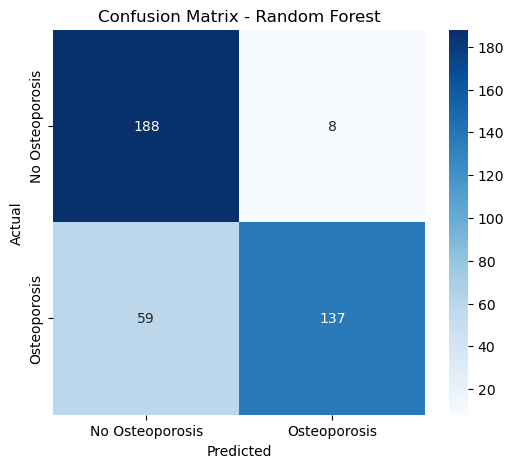

In [122]:
# heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Osteoporosis', 'Osteoporosis'],
    yticklabels=['No Osteoporosis', 'Osteoporosis']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [123]:
# K-Nearest Neighbors

In [124]:
# import knn

from sklearn.neighbors import KNeighborsClassifier


In [125]:
# train the model

knn_model = KNeighborsClassifier(n_neighbors=5)          # tells it to consider the 5 nearest data points when making a prediction

knn_model.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [126]:
# make predictions

y_pred_knn = knn_model.predict(X_test)

print(y_pred_knn[:10])

[0 0 1 0 0 1 1 1 1 0]


In [127]:
# accuracy

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.8341836734693877


In [128]:
# classification report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.77      0.96      0.85       196
           1       0.95      0.71      0.81       196

    accuracy                           0.83       392
   macro avg       0.86      0.83      0.83       392
weighted avg       0.86      0.83      0.83       392



In [129]:
# confusion matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

[[188   8]
 [ 57 139]]


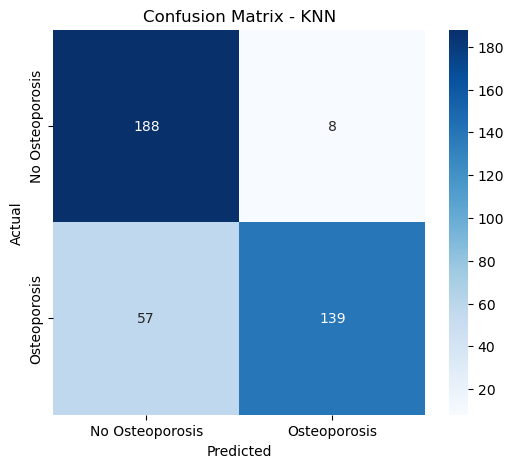

In [130]:
# heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Osteoporosis', 'Osteoporosis'],
    yticklabels=['No Osteoporosis', 'Osteoporosis']
)

plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [131]:
# models comparison table

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_tree,
        accuracy_rf,
        accuracy_knn
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.808673
1,Decision Tree,0.818878
2,Random Forest,0.829082
3,KNN,0.834184


In [132]:
model_comparison['Accuracy'] = model_comparison['Accuracy'] * 100

model_comparison

,Model,Accuracy
0,Logistic Regression,80.867347
1,Decision Tree,81.887755
2,Random Forest,82.908163
3,KNN,83.418367


In [133]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_metrics = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ]
})

model_metrics.round(3)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.809,0.858,0.740,0.795
1,Decision Tree,0.819,0.838,0.791,0.814
2,Random Forest,0.829,0.945,0.699,0.804
3,KNN,0.834,0.946,0.709,0.810


In [134]:
# feature importance

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,Age,0.645900
15,Prior Fractures_Yes,0.026998
1,Gender_Male,0.025849
2,Hormonal Changes_Postmenopausal,0.025628
7,Calcium Intake_Low,0.025467
11,Alcohol Consumption_Unknown,0.025452
10,Smoking_Yes,0.025091
6,Body Weight_Underweight,0.024486
3,Family History_Yes,0.024260
8,Vitamin D Intake_Sufficient,0.024023


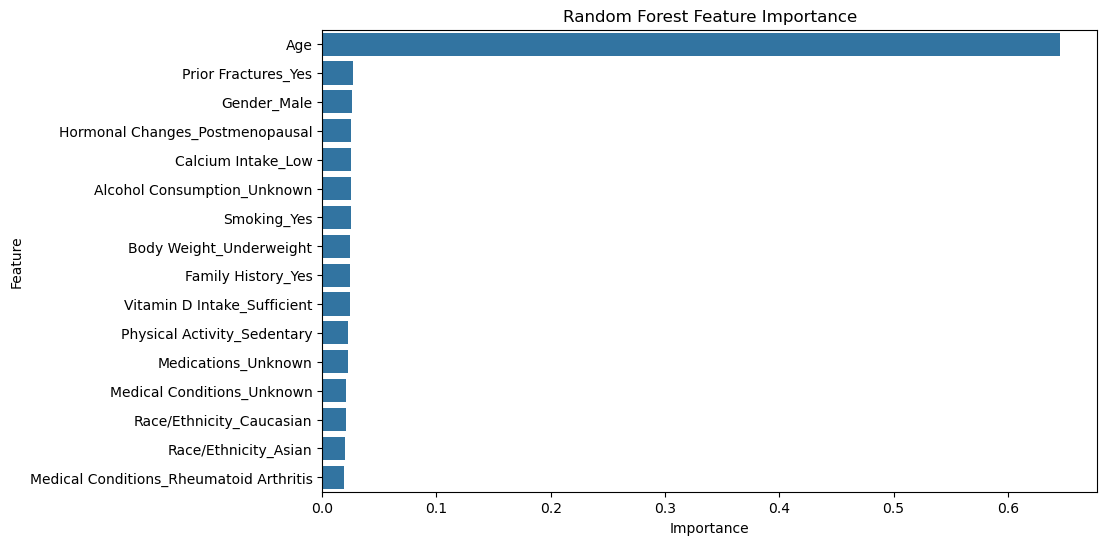

In [135]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [136]:
# ROC-AUC Evaluation

In [137]:
# AUC measures how well the model can distinguish between the two classes across different classification thresholds

from sklearn.metrics import roc_auc_score

auc_logistic = roc_auc_score(
    y_test,
    logistic_model.predict_proba(X_test)[:, 1]
)

auc_tree = roc_auc_score(
    y_test,
    decision_tree_model.predict_proba(X_test)[:, 1]
)

auc_rf = roc_auc_score(
    y_test,
    random_forest_model.predict_proba(X_test)[:, 1]
)

auc_knn = roc_auc_score(
    y_test,
    knn_model.predict_proba(X_test)[:, 1]
)

print("Logistic Regression AUC:", auc_logistic)
print("Decision Tree AUC:", auc_tree)
print("Random Forest AUC:", auc_rf)
print("KNN AUC:", auc_knn)

Logistic Regression AUC: 0.8796334860474803
Decision Tree AUC: 0.8188775510204082
Random Forest AUC: 0.88621928363182
KNN AUC: 0.8827311536859641


In [138]:
model_metrics['AUC'] = [
    auc_logistic,
    auc_tree,
    auc_rf,
    auc_knn
]

model_metrics.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.809,0.858,0.740,0.795,0.880
1,Decision Tree,0.819,0.838,0.791,0.814,0.819
2,Random Forest,0.829,0.945,0.699,0.804,0.886
3,KNN,0.834,0.946,0.709,0.810,0.883


In [139]:
# ROC_AUC Comparison

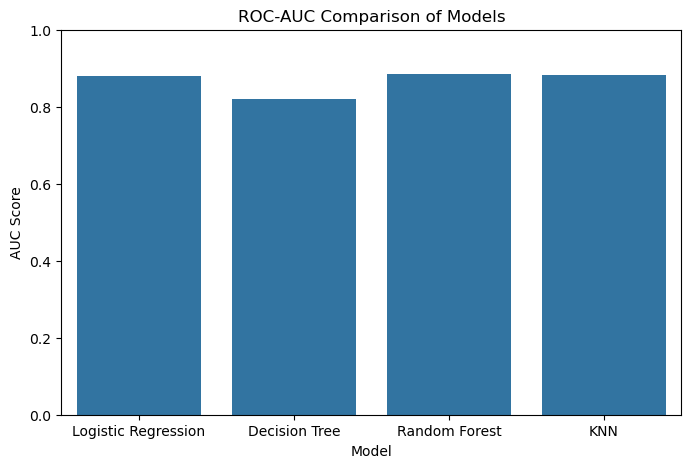

In [140]:
plt.figure(figsize=(8, 5))

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']
auc_scores = [auc_logistic, auc_tree, auc_rf, auc_knn]

sns.barplot(x=models, y=auc_scores)

plt.title('ROC-AUC Comparison of Models')
plt.xlabel('Model')
plt.ylabel('AUC Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [141]:
# Model Validation

In [142]:
# Cross-Validation

In [143]:
from sklearn.model_selection import cross_val_score

cv_logistic = cross_val_score(
    logistic_model, X_train, y_train, cv=5, scoring='accuracy'
)

cv_tree = cross_val_score(
    decision_tree_model, X_train, y_train, cv=5, scoring='accuracy'
)

cv_rf = cross_val_score(
    random_forest_model, X_train, y_train, cv=5, scoring='accuracy'
)

cv_knn = cross_val_score(
    knn_model, X_train, y_train, cv=5, scoring='accuracy'
)

print("Logistic Regression CV Accuracy:", cv_logistic.mean())
print("Decision Tree CV Accuracy:", cv_tree.mean())
print("Random Forest CV Accuracy:", cv_rf.mean())
print("KNN CV Accuracy:", cv_knn.mean())

Logistic Regression CV Accuracy: 0.8269672981827801
Decision Tree CV Accuracy: 0.8525040190472314
Random Forest CV Accuracy: 0.860794448627419
KNN CV Accuracy: 0.8729309537860444


In [144]:
## Hyper parameter tuning

In [145]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search_knn.fit(X_train, y_train)

print("Best Parameters:", grid_search_knn.best_params_)
print("Best Cross-Validation Accuracy:", grid_search_knn.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.8844244113876396


In [146]:
# create tuned knn model

In [147]:
best_knn_model = grid_search_knn.best_estimator_

best_knn_model.fit(X_train, y_train)

print("Tuned KNN model trained successfully.")

Tuned KNN model trained successfully.


In [148]:
# Prediction and accuracy

y_pred_best_knn = best_knn_model.predict(X_test)

accuracy_best_knn = accuracy_score(y_test, y_pred_best_knn)

print("Tuned KNN Accuracy:", accuracy_best_knn)

Tuned KNN Accuracy: 0.8520408163265306


In [149]:
from sklearn.metrics import classification_report

print("Tuned KNN Classification Report:")
print(classification_report(y_test, y_pred_best_knn))

Tuned KNN Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.99      0.87       196
           1       0.99      0.71      0.83       196

    accuracy                           0.85       392
   macro avg       0.88      0.85      0.85       392
weighted avg       0.88      0.85      0.85       392



In [150]:
# confusion matrix

from sklearn.metrics import confusion_matrix

cm_best_knn = confusion_matrix(y_test, y_pred_best_knn)

print("Tuned KNN Confusion Matrix:")
print(cm_best_knn)

Tuned KNN Confusion Matrix:
[[194   2]
 [ 56 140]]


In [151]:
# ROC-AUC

auc_best_knn = roc_auc_score(
    y_test,
    best_knn_model.predict_proba(X_test)[:, 1]
)

print("Tuned KNN ROC-AUC:", auc_best_knn)

Tuned KNN ROC-AUC: 0.8763275718450646


In [152]:
# Final Model Selection

In [153]:
# Limitations

In [154]:
# Conclusion